Pipeline preprocessing + model
Stwórz sklearn Pipeline z StandardScaler + PCA + LogisticRegression.

Dataset: 
from sklearn.datasets import load_digits
 Wczytanie danych
digits = load_digits()
X, y = digits.data, digits.target

Wymagania:
Pipeline z 3 krokami
Cross-validation na całym pipeline
Porównaj z modelem bez PCA

In [2]:
import numpy as np
from sklearn.datasets import load_digits
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold

# Dane
digits = load_digits()
X, y = digits.data, digits.target

# Ustawienia walidacji
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
clf = LogisticRegression(max_iter=2000, solver='lbfgs', random_state=42)

# Pipeline z PCA
pipe_pca = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=30, random_state=42)),
    ('clf', clf)
])

# Pipeline bez PCA
pipe_no_pca = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', clf)
])

# Ocena (accuracy)
scores_pca = cross_val_score(pipe_pca, X, y, cv=cv, scoring='accuracy', n_jobs=-1)
scores_no_pca = cross_val_score(pipe_no_pca, X, y, cv=cv, scoring='accuracy', n_jobs=-1)

print("With PCA:    mean={:.4f}, std={:.4f}, scores={}".format(scores_pca.mean(), scores_pca.std(), np.round(scores_pca,4)))
print("Without PCA: mean={:.4f}, std={:.4f}, scores={}".format(scores_no_pca.mean(), scores_no_pca.std(), np.round(scores_no_pca,4)))


With PCA:    mean=0.9594, std=0.0078, scores=[0.9639 0.9611 0.9666 0.9443 0.961 ]
Without PCA: mean=0.9711, std=0.0037, scores=[0.9694 0.9667 0.9777 0.9721 0.9694]


Zadanie 12.  
Learning Curves
Wygeneruj i zinterpretuj learning curves dla dwóch modeli.
Dataset: Digits

Wymagania:
Decision Tree (max_depth=None) - potencjalny overfitting
Random Forest (n_estimators=50, max_depth=5) - zbalansowany
Wykresy obok siebie z interpretacją

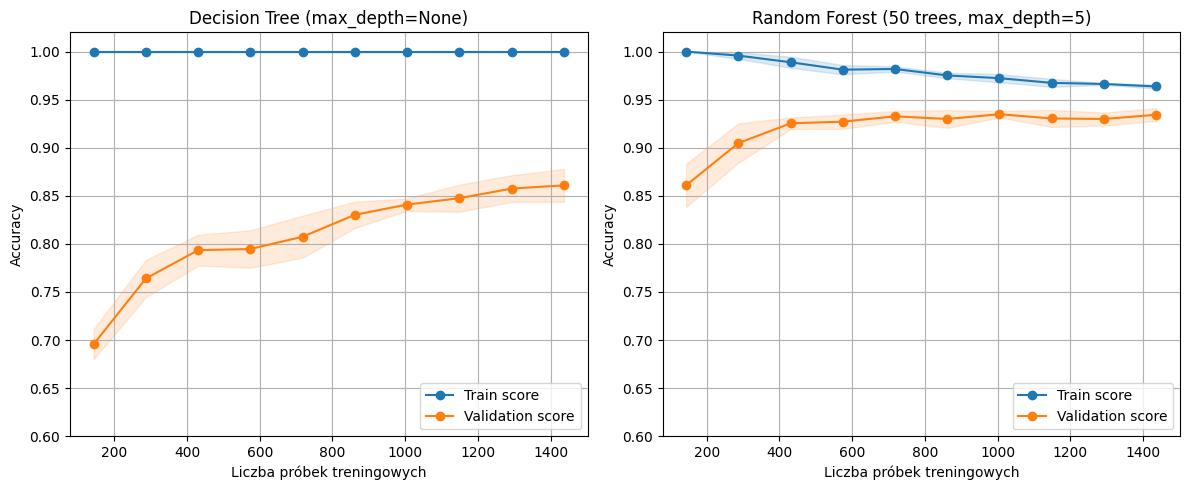

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import learning_curve, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Dane
digits = load_digits()
X, y = digits.data, digits.target

# Walidacja krzyżowa
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Modele (w pipeline skalujemy, choć drzewa tego nie wymagają - dla porównywalności)
dt = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', DecisionTreeClassifier(max_depth=None, random_state=42))
])

rf = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', RandomForestClassifier(n_estimators=50, max_depth=5, random_state=42, n_jobs=-1))
])

models = [('Decision Tree (max_depth=None)', dt), ('Random Forest (50 trees, max_depth=5)', rf)]

# Parametry learning curve
train_sizes = np.linspace(0.1, 1.0, 10)
scoring = 'accuracy'
n_jobs = -1

plt.figure(figsize=(12,5))

for i, (name, model) in enumerate(models, 1):
    train_sizes_abs, train_scores, valid_scores = learning_curve(
        estimator=model,
        X=X,
        y=y,
        train_sizes=train_sizes,
        cv=cv,
        scoring=scoring,
        n_jobs=n_jobs,
        shuffle=True,
        random_state=42
    )
    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    valid_mean = np.mean(valid_scores, axis=1)
    valid_std = np.std(valid_scores, axis=1)

    ax = plt.subplot(1, 2, i)
    ax.plot(train_sizes_abs, train_mean, 'o-', color='tab:blue', label='Train score')
    ax.fill_between(train_sizes_abs, train_mean - train_std, train_mean + train_std, alpha=0.15, color='tab:blue')
    ax.plot(train_sizes_abs, valid_mean, 'o-', color='tab:orange', label='Validation score')
    ax.fill_between(train_sizes_abs, valid_mean - valid_std, valid_mean + valid_std, alpha=0.15, color='tab:orange')
    ax.set_title(name)
    ax.set_xlabel('Liczba próbek treningowych')
    ax.set_ylabel('Accuracy')
    ax.set_ylim(0.6, 1.02)
    ax.grid(True)
    ax.legend(loc='lower right')

plt.tight_layout()
plt.show()
